# Schedulazione del percorso critico per il lancio di un prodotto assicurativo auto

## Sintesi esecutiva

Il lancio di un prodotto assicurativo auto per privati è un programma interfunzionale: gli attuari tariffano il rischio, la compliance deposita le tariffe presso lo Stato e attende l'approvazione, l'IT configura il sistema di amministrazione delle polizze e la distribuzione forma gli agenti. Queste attività hanno rigide relazioni di precedenza, per cui la data di lancio è determinata dalla catena dipendente più lunga attraverso il piano -- il **percorso critico**.

Questo notebook costruisce una rete di progetto Activity-on-Node di undici attività di lancio e calcola una schedulazione completa con il **Metodo del Percorso Critico (CPM)** tramite **PROC OPTMODEL**. I passaggi in avanti e all'indietro del CPM sono programmi lineari sul grafo di precedenza: il passaggio in avanti (percorso più lungo dall'inizio) fornisce l'inizio e la fine più anticipati di ogni attività, mentre un passaggio all'indietro sul percorso più lungo fornisce l'inizio e la fine più tardivi e lo **scorrimento totale** (margine di schedulazione). I risultati qui sotto sono prodotti interamente dal codice di questo notebook -- ogni numero nella narrazione è riletto dall'output eseguito.

**Cosa mostra la schedulazione.** Su un calendario lavorativo di cinque giorni ancorato al 01JUN2026, il programma si estende per **97 giorni lavorativi** e termina il **13OCT2026**. Nove delle undici attività si trovano sul percorso critico (Kickoff -> Ricerca di mercato -> Assemblaggio dei dati di sinistro -> Tariffazione -> Progettazione del sistema -> Costruzione del sistema -> UAT -> Formazione degli agenti -> Lancio) e presentano scorrimento nullo. Solo il ramo normativo -- **deposito delle tariffe** e **approvazione** -- ha margine: ciascuno può slittare fino a **30 giorni lavorativi** senza spostare il lancio, perché il ramo parallelo di costruzione del sistema è il più lungo dei due percorsi convergenti.

## Come è costruito

Il CPM è classicamente una procedura SAS/OR, ma il suo calcolo di base è una coppia di problemi di percorso più lungo sul grafo di precedenza, che PROC OPTMODEL esprime direttamente come piccoli programmi lineari:

- **Passaggio in avanti (tempi più anticipati).** Minimizza le variabili di inizio più anticipato soggette a `ES[successore] >= ES[predecessore] + durata + lag` per ogni arco di precedenza. All'ottimo ogni `ES` è pari al percorso più lungo dall'inizio del progetto, cioè il momento più anticipato in cui l'attività può cominciare.
- **Passaggio all'indietro (tempi più tardivi / scorrimento).** Calcola, per ogni attività, il percorso rimanente più lungo fino alla fine del progetto (`TAIL`). L'inizio più tardivo è quindi `makespan - TAIL`, e lo **scorrimento totale** è `inizio tardivo - inizio anticipato`. Le attività con scorrimento nullo sono critiche.

La rete, le durate, i lag di precedenza e le richieste di risorse per attività sono tutti generati inline; non ci sono input esterni. Le date di calendario in giorni lavorativi sono ricavate con `INTNX('weekday', ...)` in modo che i fine settimana vengano saltati.

## Dati

| Dataset | Righe | Variabili chiave | Descrizione |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Anagrafica delle attività: ogni attività di lancio, la sua durata in giorni lavorativi e il fabbisogno giornaliero di attuari / sviluppatori |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Archi di precedenza della rete Activity-on-Node; `lag` è un ritardo finish-to-start in giorni lavorativi (il periodo di attesa normativo dopo l'approvazione) |

Gli ID numerici delle attività fanno da chiave alla rete, così il grafo di precedenza si legge in modo pulito nell'insieme di tuple di OPTMODEL; i nomi leggibili `activity` vengono poi riuniti alla schedulazione.

In [1]:
DATI acts;
   LUNGHEZZA activity $36;
   INFILE DATALINES DLM='|';
   INGRESSO id activity $ dur actuary developer;
   DATALINES;
1|Kickoff|3|1|0
2|Ricerca di mercato|8|2|0
3|Assemblaggio dei dati di sinistro|10|3|0
4|Tariffazione|9|3|1
5|Deposito delle tariffe|4|1|0
6|Approvazione|6|1|0
7|Progettazione del sistema|12|1|2
8|Costruzione del sistema|18|0|3
9|UAT|15|0|2
10|Formazione degli agenti|20|1|1
11|Lancio|2|1|1
;
ESEGUIRE;

DATI arcs;
   INGRESSO pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
ESEGUIRE;

/* vista solo numerica delle durate per OPTMODEL */
DATI acts_n; IMPOSTARE acts; MANTENERE id dur; ESEGUIRE;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Passaggio in avanti -- inizio e fine più anticipati

Il passaggio in avanti è un LP di percorso più lungo. Il vincolo `ES[j] >= ES[i] + dur[i] + lag[i,j]` per ogni arco impone a ciascuna attività di non iniziare prima che tutti i suoi predecessori terminino (più eventuali lag normativi); minimizzare le variabili di inizio più anticipato le spinge ciascuna verso il percorso predecessore più lungo. Scriviamo i valori risolti di `ES` direttamente dalla variabile OPTMODEL in `fwd`.

In [2]:
PROCEDURA optmodel;
   IMPOSTARE NODES; num dur{NODES};
   READ DATI acts_n INTO NODES=[id] dur=dur;

   IMPOSTARE <num,num> ARCS; num lag{ARCS};
   READ DATI arcs INTO ARCS=[pred succ] lag=lag;

   VARIABILE ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREARE DATI fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Passaggio all'indietro -- tempi più tardivi e scorrimento totale

`TAIL[a]` è il percorso più lungo dall'attività `a` fino alla fine del progetto, quindi deve coprire la durata dell'attività stessa e, per ogni successore, il lag più il tail di quel successore: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimizzare i tail produce i valori più stretti possibili. Il **makespan** del progetto è la fine più anticipata più grande; l'**inizio tardivo** di ogni attività è `makespan - TAIL`, e lo **scorrimento totale** è `inizio tardivo - inizio anticipato`. Uno scorrimento nullo segna il percorso critico.

In [3]:
PROCEDURA optmodel;
   IMPOSTARE NODES; num dur{NODES};
   READ DATI acts_n INTO NODES=[id] dur=dur;

   IMPOSTARE <num,num> ARCS; num lag{ARCS};
   READ DATI arcs INTO ARCS=[pred succ] lag=lag;

   VARIABILE TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREARE DATI bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Assemblare la schedulazione e il calendario

Riuniamo gli inizi più anticipati e i tail all'anagrafica delle attività, ricaviamo l'inizio / la fine più tardivi e lo scorrimento totale, e mappiamo gli offset in giorni lavorativi in date di calendario con `INTNX('weekday', ...)` in modo che le date cadano su giorni lavorativi. Un'attività viene contrassegnata come **critica** quando il suo scorrimento totale è nullo.

In [4]:
%LET anchor = '01jun2026'd;

DATI sched0;
   UNIRE acts fwd bwd; PER id;
   ef = es + dur;            /* fine anticipata */
ESEGUIRE;

PROCEDURA MEDIE DATI=sched0 NOPRINT;
   USCITA out=mk(RIMUOVERE=_type_ _freq_) MAX(ef)=makespan;
ESEGUIRE;

DATI sched;
   SE_COND _n_=1 ALLORA IMPOSTARE mk;
   IMPOSTARE sched0;
   CONSERVARE mspan;
   SE_COND _n_=1 ALLORA mspan = makespan;
   ls = mspan - tail;        /* inizio tardivo  */
   lf = ls + dur;            /* fine tardiva    */
   tfloat = ls - es;         /* scorrimento totale */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LUNGHEZZA cclass $10;
   SE_COND critical ALLORA cclass='Critico';
   ALTRIMENTI cclass='Margine';
   FORMATO e_start e_finish l_start l_finish date9.;
ESEGUIRE;

PROCEDURA ORDINARE DATI=sched out=sched_es; PER es id; ESEGUIRE;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## La schedulazione CPM

Inizio e fine più anticipati/tardivi sono espressi in giorni lavorativi a partire dall'ancoraggio del 01JUN2026 (giorno 0). Le attività della classe **Critico** hanno scorrimento totale nullo.

In [5]:
TITOLO "Schedulazione CPM -- tempi in giorni lavorativi e scorrimento totale";
PROCEDURA STAMPARE DATI=sched_es noobs ETICHETTA;
   VARIABILE activity dur es ef ls lf tfloat cclass;
   ETICHETTA activity="Attività" dur="Durata" es="Inizio ant." ef="Fine ant."
         ls="Inizio tard." lf="Fine tard." tfloat="Scorrimento totale" cclass="Classe";
ESEGUIRE;

                          Schedulazione CPM -- tempi in giorni lavorativi e scorrimento totale                          


                         Attività  Durata  Inizio ant.  Fine ant.  Inizio tard.  Fine tard.  Scorrimento totale   Classe
---------------------------------  ------  -----------  ---------  ------------  ----------  ------------------  -------
Kickoff                                 3            0          3             0           3                   0  Critico
Ricerca di mercato                      8            3         11             3          11                   0  Critico
Assemblaggio dei dati di sinistro      10           11         21            11          21                   0  Critico
Tariffazione                            9           21         30            21          30                   0  Critico
Deposito delle tariffe                  4           30         34            60          64                  30  Margine
Progettazione del sistema     


NOTE: Option TITLE changed to Schedulazione CPM -- tempi in giorni lavorativi e scorrimento totale.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


La colonna dell'inizio più anticipato traccia la catena dipendente: Kickoff inizia al giorno 0, e ogni attività a valle parte quando i suoi predecessori terminano. Il progetto si completa alla fine più anticipata più grande.

## Il percorso critico

Elencando solo le attività con scorrimento nullo, con le loro date di calendario, si ottiene la catena che determina la data di lancio. Qualsiasi slittamento su queste attività sposta il giorno di lancio giorno per giorno.

In [6]:
TITOLO "Percorso critico (scorrimento totale = 0) con date di calendario";
PROCEDURA STAMPARE DATI=sched_es noobs ETICHETTA;
   DOVE critical=1;
   VARIABILE activity dur e_start e_finish;
   ETICHETTA activity="Attività" dur="Durata"
         e_start="Inizio anticipato" e_finish="Fine anticipata";
ESEGUIRE;

DATI mkrep;
   IMPOSTARE mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   FORMATO anchor FINISH date9.;
ESEGUIRE;
TITOLO "Durata complessiva del progetto";
PROCEDURA STAMPARE DATI=mkrep noobs ETICHETTA;
   VARIABILE anchor makespan FINISH;
   ETICHETTA anchor="Ancoraggio (giorno 0)"
         makespan="Makespan (giorni lavorativi)"
         FINISH="Fine prevista";
ESEGUIRE;

                            Percorso critico (scorrimento totale = 0) con date di calendario                            


                         Attività  Durata  Inizio anticipato  Fine anticipata
---------------------------------  ------  -----------------  ---------------
Kickoff                                 3          01JUN2026        03JUN2026
Ricerca di mercato                      8          04JUN2026        15JUN2026
Assemblaggio dei dati di sinistro      10          16JUN2026        29JUN2026
Tariffazione                            9          30JUN2026        10JUL2026
Progettazione del sistema              12          13JUL2026        28JUL2026
Costruzione del sistema                18          29JUL2026        21AUG2026
UAT                                    15          24AUG2026        11SEP2026
Formazione degli agenti                20          14SEP2026        09OCT2026
Lancio                                  2          12OCT2026        13OCT2026

                  


NOTE: Option TITLE changed to Percorso critico (scorrimento totale = 0) con date di calendario.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Durata complessiva del progetto.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Dove si trova il margine

Le attività non critiche costituiscono il ramo normativo. Il loro inizio / la loro fine più tardivi mostrano di quanto ciascuna può spostarsi prima di iniziare a spingere il lancio. Qui lo scorrimento libero è pari allo scorrimento totale perché nessun'altra attività dipende da esse fino a quando non si ricongiungono alla formazione degli agenti.

In [7]:
TITOLO "Attività non critiche e loro margine di schedulazione";
PROCEDURA STAMPARE DATI=sched_es noobs ETICHETTA;
   DOVE critical=0;
   VARIABILE activity dur e_start e_finish l_start l_finish tfloat;
   ETICHETTA activity="Attività" dur="Durata"
         e_start="Inizio anticipato" e_finish="Fine anticipata"
         l_start="Inizio tardivo" l_finish="Fine tardiva"
         tfloat="Scorrimento totale";
ESEGUIRE;

                                 Attività non critiche e loro margine di schedulazione                                  


              Attività  Durata  Inizio anticipato  Fine anticipata  Inizio tardivo  Fine tardiva  Scorrimento totale
----------------------  ------  -----------------  ---------------  --------------  ------------  ------------------
Deposito delle tariffe       4          13JUL2026        16JUL2026       24AUG2026     27AUG2026                  30
Approvazione                 6          17JUL2026        24JUL2026       28AUG2026     04SEP2026                  30




NOTE: Option TITLE changed to Attività non critiche e loro margine di schedulazione.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Cascata della schedulazione

Una barra high-low per attività, tracciata dal suo inizio più anticipato alla sua fine più anticipata in ordine di progetto, fornisce una cascata in stile Gantt del piano. L'altezza di ogni barra è la durata dell'attività, e la scalinata sale fino al makespan di 97 giorni lavorativi. Le attività che stanno *sotto* la diagonale ascendente -- dove la cima di una barra è più bassa del fondo della barra successiva -- sono quelle con margine.

                             Lancio prodotto auto -- cascata della schedulazione anticipata                             




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Lancio prodotto auto -- cascata della schedulazione anticipata.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


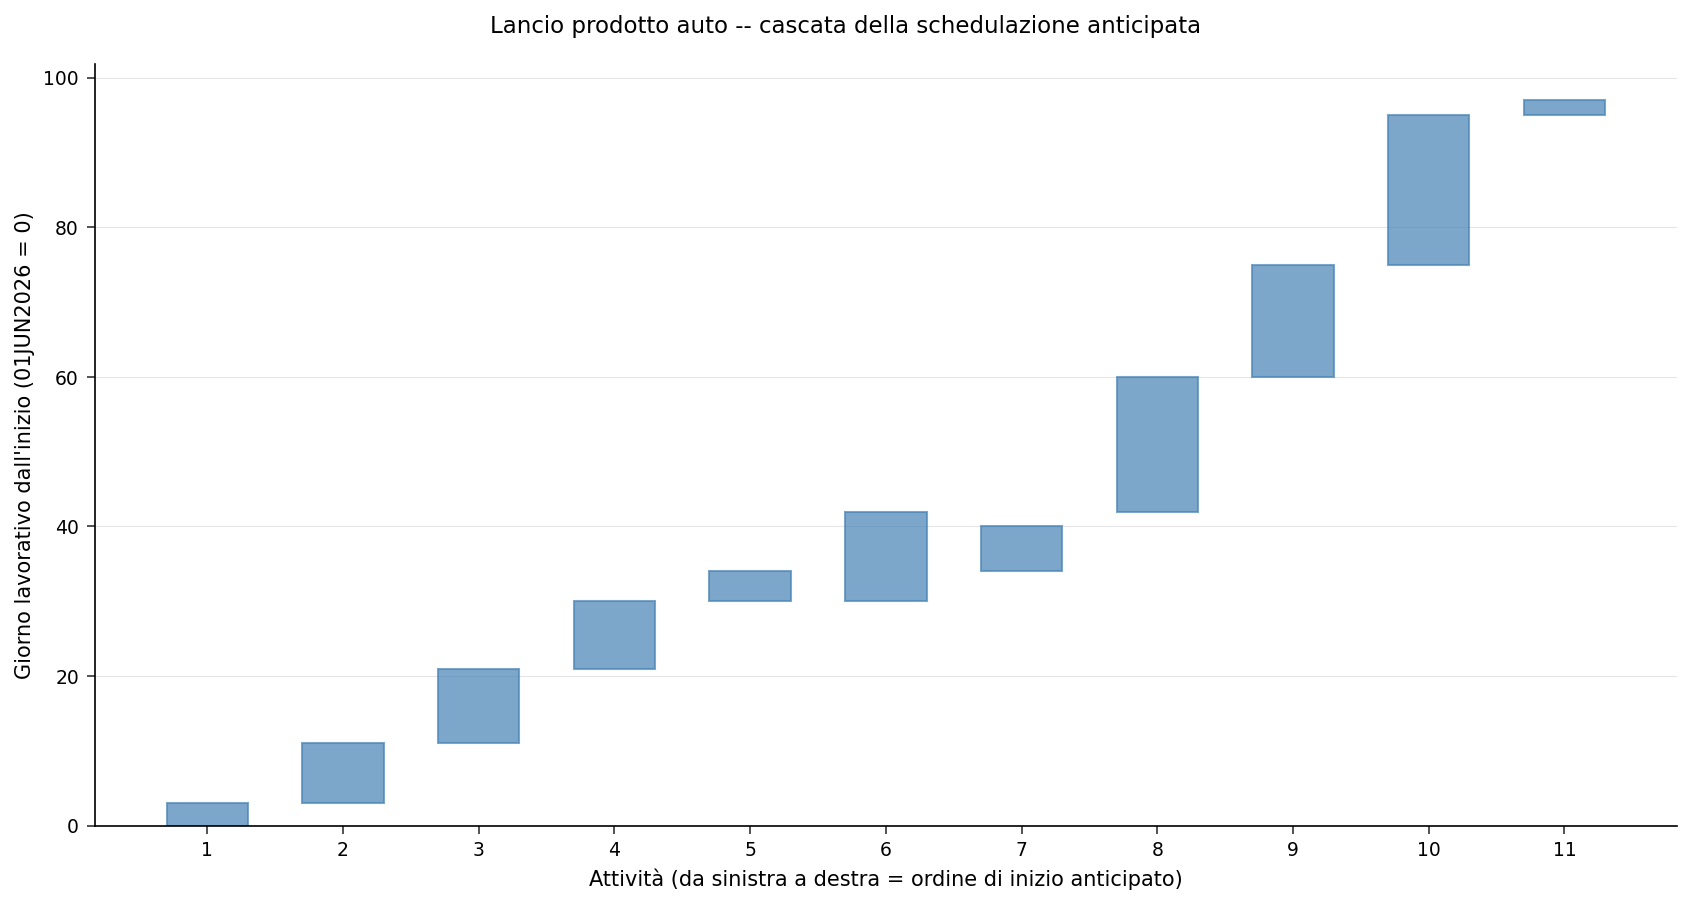

In [8]:
DATI gantt; IMPOSTARE sched_es;
   ord = es;          /* x numerico = ordine di inizio anticipato */
ESEGUIRE;
PROCEDURA ORDINARE DATI=gantt; PER ord activity; ESEGUIRE;
DATI gantt; IMPOSTARE gantt; ax = _n_; ESEGUIRE;   /* indice x compatto 1..11 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TITOLO "Lancio prodotto auto -- cascata della schedulazione anticipata";
PROCEDURA SGPLOT DATI=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS ETICHETTA="Attività (da sinistra a destra = ordine di inizio anticipato)"
         integer VALUES=(1 FINO_A 11 PER 1);
   YAXIS ETICHETTA="Giorno lavorativo dall'inizio (01JUN2026 = 0)" grid;
ESEGUIRE;
ODS GRAPHICS OFF;

Leggendo da sinistra a destra, le barre salgono in modo continuo lungo la catena critica. Le due attività le cui barre spezzano la scalinata -- iniziando più in basso della cima della barra precedente -- sono il deposito delle tariffe e l'approvazione, le attività che portano scorrimento.

## Scorrimento totale per attività

Rappresentando lo scorrimento totale di ogni attività il percorso critico diventa inconfondibile: ogni attività critica si trova a zero, e solo le due attività normative si elevano al di sopra.

                               Scorrimento totale per attività (0 = sul percorso critico)                               




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Scorrimento totale per attività (0 = sul percorso critico).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


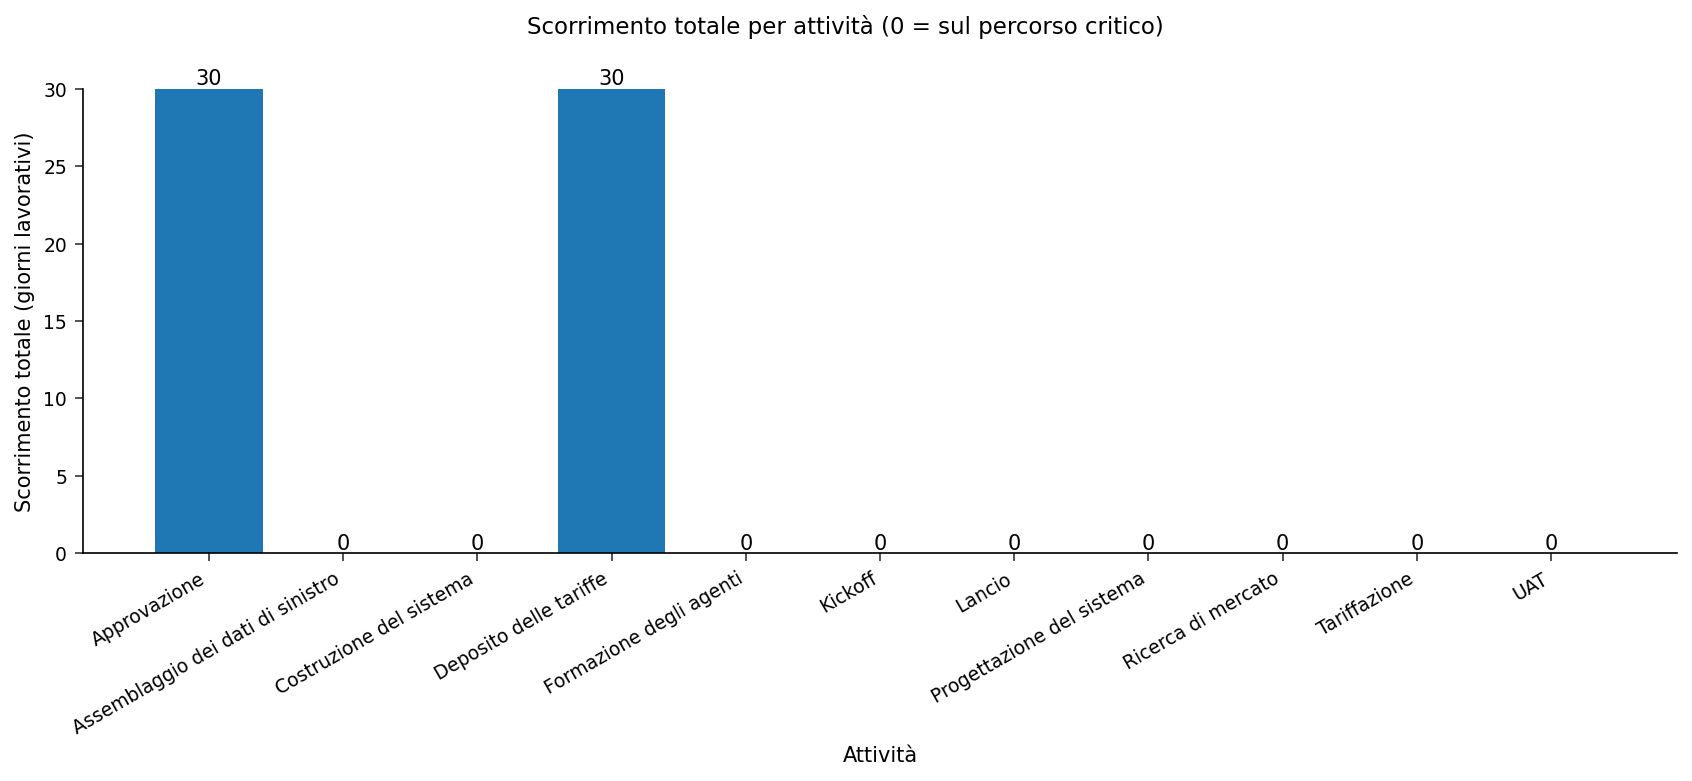

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TITOLO "Scorrimento totale per attività (0 = sul percorso critico)";
PROCEDURA SGPLOT DATI=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS ETICHETTA="Attività" fitpolicy=rotatethin;
   YAXIS ETICHETTA="Scorrimento totale (giorni lavorativi)";
ESEGUIRE;
ODS GRAPHICS OFF;

## Carico delle risorse nella schedulazione anticipata

Oltre alla tempistica, il piano compete per due pool di specialisti. Espandendo ogni attività lungo i giorni lavorativi che occupa e sommando la domanda giornaliera si ottiene il profilo di carico delle risorse -- quanti attuari e sviluppatori richiede il piano ogni giorno se ogni attività inizia il più presto possibile. Il picco è la massima capacità che il programma richiede in una volta sola.

                         Picco giornaliero del carico delle risorse (schedulazione anticipata)                          

                                                  The MEANS Procedure

 Variable    Label            Maximum
 ------------------------------------
 ACTUARIES   Attuari                3
 DEVELOPERS  Sviluppatori           3
 ------------------------------------

                      Carico giornaliero di attuari e sviluppatori nella schedulazione anticipata                       




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Picco giornaliero del carico delle risorse (schedulazione anticipata).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Carico giornaliero di attuari e sviluppatori nella schedulazione anticipata.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


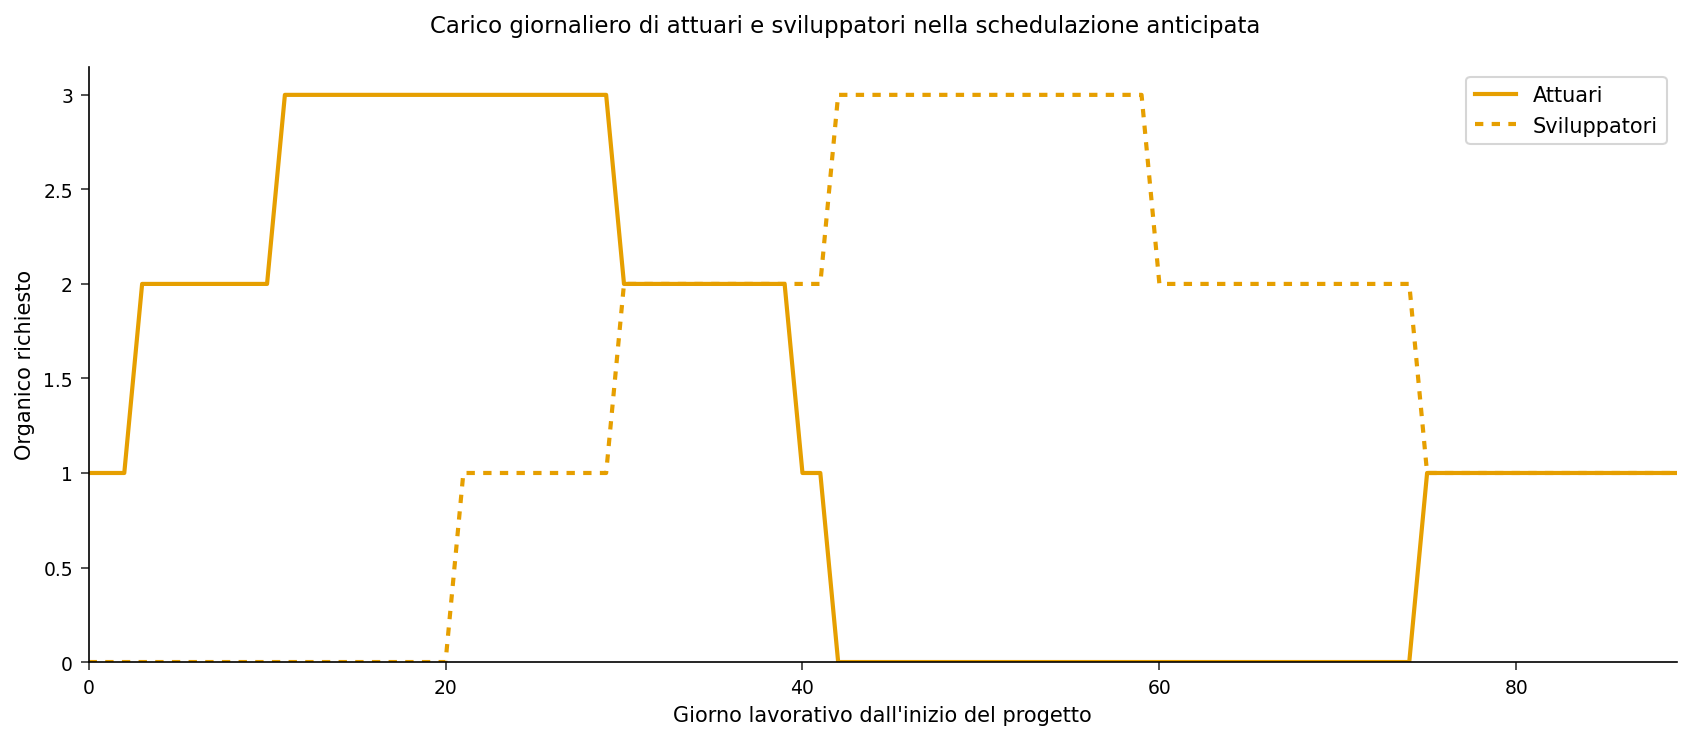

In [10]:
DATI LOAD;
   IMPOSTARE sched;
   FARE d = es FINO_A ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      USCITA;
   FINE;
   MANTENERE day a_use d_use;
ESEGUIRE;

PROCEDURA MEDIE DATI=LOAD NOPRINT NWAY;
   CLASSE day;
   VARIABILE a_use d_use;
   USCITA out=rprofile(RIMUOVERE=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
ESEGUIRE;
PROCEDURA ORDINARE DATI=rprofile; PER day; ESEGUIRE;

TITOLO "Picco giornaliero del carico delle risorse (schedulazione anticipata)";
PROCEDURA MEDIE DATI=rprofile MAX maxdec=0;
   VARIABILE actuaries developers;
   ETICHETTA actuaries="Attuari" developers="Sviluppatori";
ESEGUIRE;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TITOLO "Carico giornaliero di attuari e sviluppatori nella schedulazione anticipata";
PROCEDURA SGPLOT DATI=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel="Attuari";
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel="Sviluppatori";
   XAXIS ETICHETTA="Giorno lavorativo dall'inizio del progetto";
   YAXIS ETICHETTA="Organico richiesto" MIN=0;
   keylegend / location=inside position=topright;
ESEGUIRE;
ODS GRAPHICS OFF;

## Interpretazione dei risultati

- **La data di lancio è determinata dal percorso di costruzione, non da quello normativo.** Il percorso critico segue Kickoff -> Ricerca di mercato -> Assemblaggio dei dati di sinistro -> Tariffazione -> Progettazione del sistema -> Costruzione del sistema -> UAT -> Formazione degli agenti -> Lancio, per un makespan di 97 giorni lavorativi (con termine il 13OCT2026). Ognuna di queste attività ha scorrimento nullo, quindi qualsiasi ritardo su di esse spinge il lancio giorno per giorno.

- **Il ramo normativo ha un mese di margine.** Il deposito delle tariffe e l'approvazione portano ciascuno 30 giorni lavorativi di scorrimento totale. Dopo il termine della tariffazione possono iniziare fino alle loro date di inizio più tardivo e ricongiungersi comunque in tempo alla formazione degli agenti, perché il ramo parallelo di costruzione del sistema (progettazione del sistema -> costruzione del sistema -> UAT) è il più lungo dei due percorsi che alimentano il lancio. In termini di pianificazione, il deposito *non* è il vincolo determinante qui -- lo è la costruzione del sistema di polizze.

- **La domanda di specialisti raggiunge il picco in fasi diverse.** Il profilo di carico mostra la domanda di attuari al picco all'inizio (fino alla tariffazione) e la domanda di sviluppatori al picco più tardi (fino alla costruzione del sistema), ciascuna con un massimo di tre persone al giorno. Poiché i due picchi cadono in fasi diverse, un piccolo team sequenziale di specialisti può coprire il piano -- il programma non ha bisogno del suo organico massimo di attuari e sviluppatori contemporaneamente.

**Conclusione per il business.** Il CPM trasforma un elenco di attività di lancio in una schedulazione operativa: identifica le attività del percorso di costruzione che l'assicuratore deve proteggere per rispettare il 13OCT2026, quantifica il mese di margine disponibile sul deposito normativo, e mostra che i picchi sfalsati di attuari e sviluppatori consentono a un team snello di specialisti di realizzare il piano.

*Nota implementativa:* SAS calcola tutto ciò con PROC CPM (SAS/OR). Jenner raggiunge lo stesso risultato di percorso critico in avanti/all'indietro con PROC OPTMODEL risolvendo i due programmi lineari di percorso più lungo che stanno alla base del metodo.